# 必须联合点火的多吸引子系统

目标：验证当任意单节点都无法切换稳态时，基于最终 basin 标签的 PEID synergy 能否发现可切换节点对。本 notebook 只负责配置、读取/执行缓存、展示核心结果和解释 claim gate。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

repo_root = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "exp/network_revival/joint_required_ignition.py").exists()
)
sys.path.insert(0, str(repo_root))

from exp.network_revival.joint_required_ignition import (
    JointRequiredIgnitionConfig,
    plot_joint_required_results,
    run_joint_required_ensemble,
)

config = JointRequiredIgnitionConfig(
    output_dir=repo_root / "results/network_revival_joint_required_ignition"
)
config

JointRequiredIgnitionConfig(output_dir=PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn/results/network_revival_joint_required_ignition'), source_count=8, theta=0.4, kappa=8.0, hill_coefficient=4.0, half_saturation=1.0, amplitude_max=4.0, amplitude_levels=16, t_force=8.0, release_time=8.0, dt=0.04, ensemble_size=50, sample_sizes=(128, 256, 512, 1024), label_noise_levels=(0.0, 0.02, 0.05, 0.1), high_weight_fraction_range=(0.62, 0.78), low_weight_fraction_range=(0.1, 0.14), pair_margin=0.06, fixed_delta=1.5, seed=20260615)

## 执行协议

- 8 个候选源节点，逐对隔离干预，共 28 对。
- 独立均匀的 $16\times16$ 幅度状态，固定点火 $T=8$ 后释放。
- 目标变量是释放后的最终 basin 标签，而不是连续终态。
- 50 个随机参数实例，并评估样本量与 basin 标签噪声鲁棒性。

In [2]:
results = run_joint_required_ensemble(config, force=False)
summary = results["summary"]
{
    "claim_gates": summary["claim_gates"],
    "support_correspondence": summary["support_correspondence"],
}

{'claim_gates': {'exact_mean_auprc': 1.0,
  'exact_mean_top_k_recall': 1.0,
  'sample512_noise005_mean_auprc': 1.0,
  'claim_gate_passed': True},
 'support_correspondence': {'criterion': 'max-pair final basin label equals 1 iff PEID synergy > 1e-12',
  'pairwise_match_rate': 1.0,
  'all_instances_exact_match': True}}

In [3]:
metrics = results['metrics']
selected = metrics.loc[(metrics['condition'] == 'exact_grid') | ((metrics['requested_sample_count'] == 512) & (metrics['label_noise'] == 0.05))]
display(selected.groupby(['condition', 'requested_sample_count', 'label_noise', 'score'])[['auprc', 'top_k_recall', 'top1_hit']].mean().round(3))
summary['and_gate_control']

auprc  \
condition  requested_sample_count label_noise score                        
exact_grid 256                    0.00        fixed_cost_response  1.000   
                                              joint_ei             1.000   
                                              random_score         0.306   
                                              single_ei_sum        1.000   
                                              synergy              1.000   
sampled    512                    0.05        fixed_cost_response  1.000   
                                              joint_ei             1.000   
                                              random_score         0.275   
                                              single_ei_sum        1.000   
                                              synergy              1.000   

                                                                   top_k_recall  \
condition  requested_sample_count label_noise score                               
exact_grid 256                    0.00        fixed_cost_response         1.000   
                                              joint_ei                    1.000   
                                              random_score                0.210   
                                              single_ei_sum               1.000   
                                              synergy                     1.000   
sampled    512                    0.05        fixed_cost_response         1.000   
                                              joint_ei                    1.000   
                                              random_score                0.203   
                                              single_ei_sum               1.000   
                                              synergy                     1.000   

                                                                   top1_hit  
condition  requested_sample_count label_noise score                          
exact_grid 256                    0.00        fixed_cost_response      1.00  
                                              joint_ei                 1.00  
                                              random_score             0.24  
                                              single_ei_sum            1.00  
                                              synergy                  1.00  
sampled    512                    0.05        fixed_cost_response      1.00  
                                              joint_ei                 1.00  
                                              random_score             0.12  
                                              single_ei_sum            1.00  
                                              synergy                  1.00

{'true_pair': [0, 1],
 'top_synergy_pair': [0, 1],
 'top_synergy': 0.23467631590425242}

## 核心图

图分别展示严格联合必要性的动力学机制、解析可切换组合与 PEID synergy 排名，以及参数集成和噪声鲁棒性。

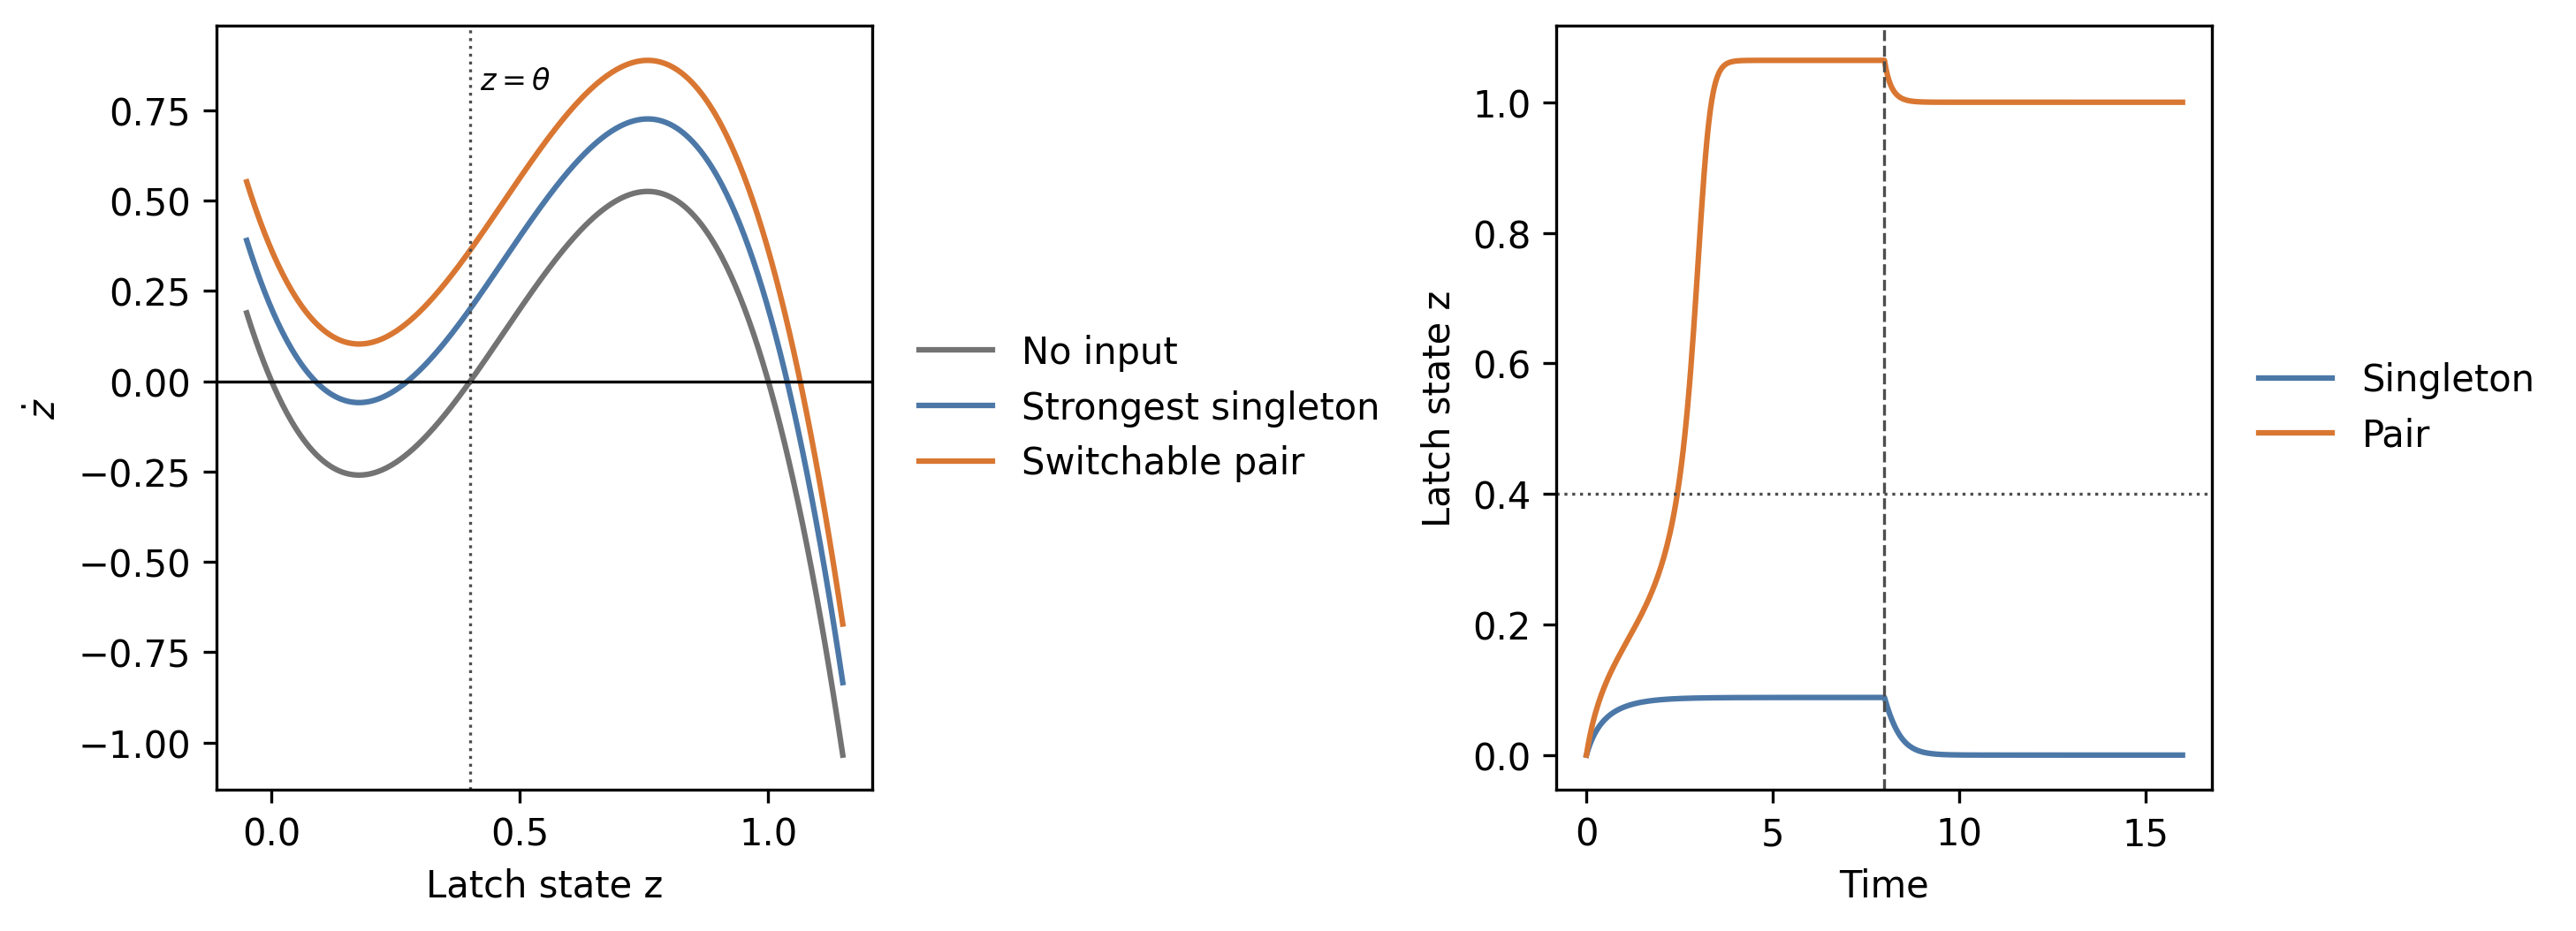

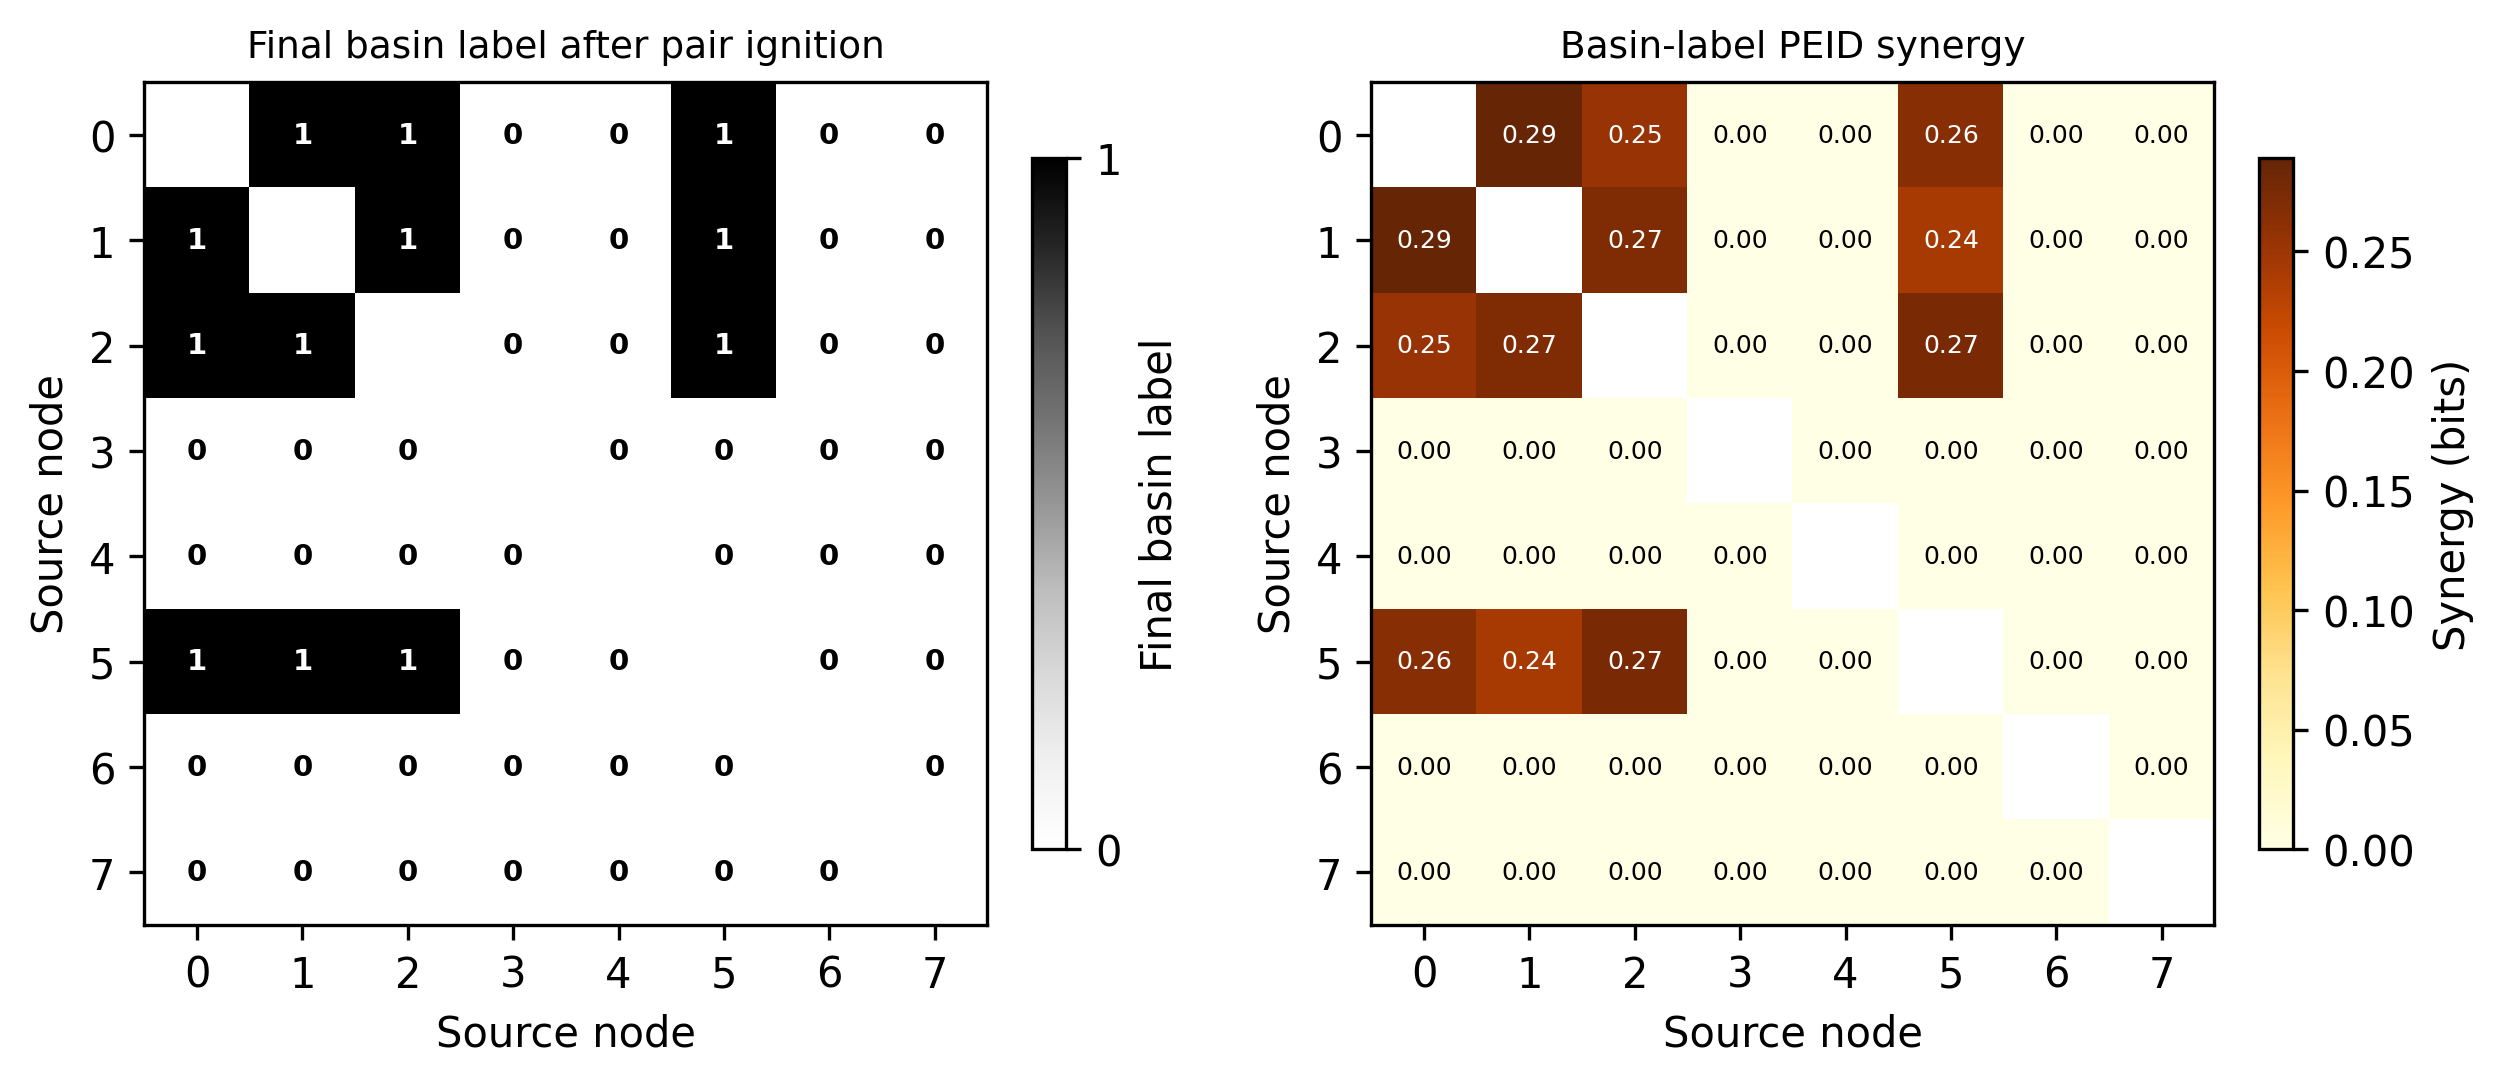

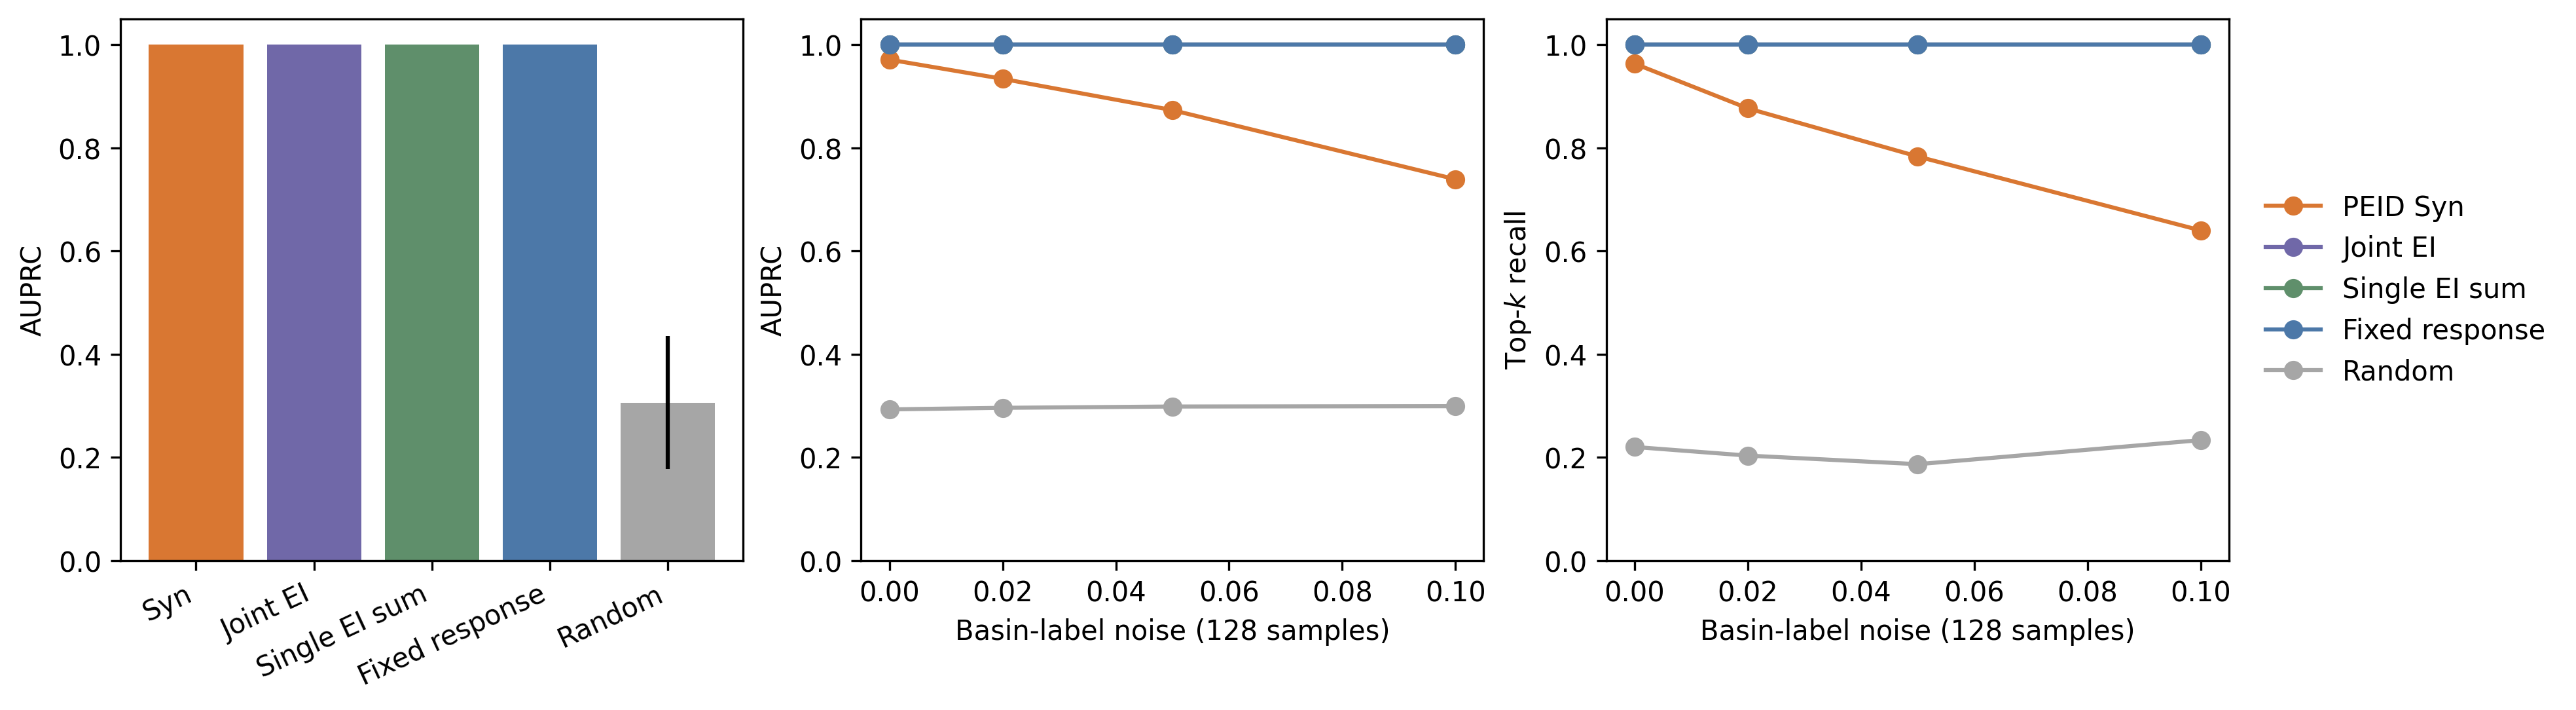

In [4]:
figure_paths = plot_joint_required_results(
    results,
    config,
    report_asset_dir=repo_root / "docs/reports/assets",
)
for item in figure_paths.values():
    display(Image(filename=str(item["png"])))

## 解释与主张边界

无噪声集成以及 512 样本、5% 标签噪声条件均通过预设 claim gate，因此 PEID synergy 在该系统中可以称为良好的组合发现测度。但 joint EI、单节点 EI 之和与固定成本响应在当前加性锁存构造中表现相当；不能声称 synergy 优于所有基线。在 128 样本与高标签噪声下，synergy 的性能下降也更明显。